In [72]:
# ЗАГРУЗКА ДАННЫХ С GITHUB

import pandas as pd

url = 'https://raw.githubusercontent.com/TimurQuich/Machine-learning-for-determining-the-ESP-overhaul-period/main/Dataset.xlsx'

try:
    df = pd.read_excel(url)
    print("✅ Данные успешно загружены с GitHub!")
except Exception as e:
    print(f"❌ Ошибка загрузки: {e}")
    print("Проверьте ссылку или загрузите файл вручную.")

✅ Данные успешно загружены с GitHub!


Добавлено новых признаков: 6
Общее количество признаков до кодирования: 13
Общее количество признаков после кодирования: 234


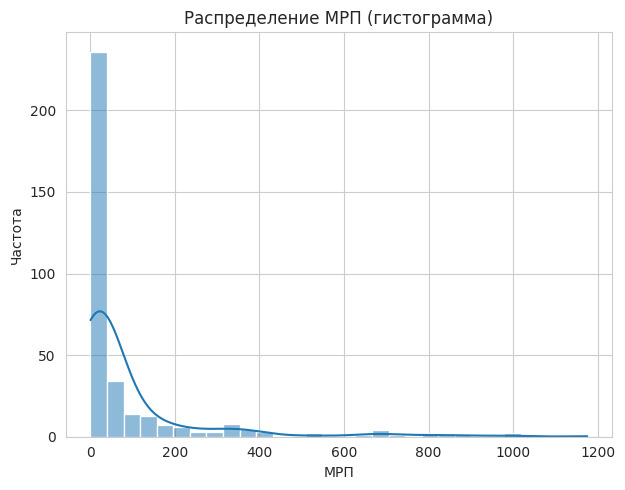

Статистики МРП:
Среднее: 88.13
Медиана: 23.00
Стандартное отклонение: 173.07
Асимметрия (Skewness): 3.43
Эксцесс (Kurtosis): 12.95
Квартили: 
25%    12.0
50%    23.0
75%    69.5
Name: МРП, dtype: float64
Итоговое количество признаков для модели: 233
Размер обучающей выборки: 277
Размер тестовой выборки: 70
Linear Regression: MAE = 113.02, RMSE = 200.18
Random Forest: MAE = 48.38, RMSE = 137.28
Gradient Boosting: MAE = 50.74, RMSE = 140.62
Extra Trees: MAE = 52.16, RMSE = 159.30

Лучший алгоритм по MAE: Random Forest
Лучший алгоритм по RMSE: Random Forest


In [73]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.linear_model import LinearRegression

# ПЕРВИЧНАЯ ПОДГОТОВКА ДАННЫХ

df = df[[
    "Модель насоса",
    "Глубина спуска, м",
    "% в",
    "МРП",
    "Qж факт",
    "Qн факт",
    "Причина остановки"
]]

# Удаление пустых строк (на случай изменения датасета)
df = df.dropna()

# СОЗДАНИЕ НОВЫХ ПРИЗНАКОВ

# Из-за небольшого объема данных было принято
# решение создать новые признаки

df_fe = df.copy()

# 1. Соотношение дебита жидкости к дебиту нефти
df_fe['Qж факт / Qн факт'] = df_fe['Qж факт'] / (df_fe['Qн факт'] + 1e-6)

# 2. Произведение глубины на обводненность
df_fe['Глубина * (% в)'] = df_fe['Глубина спуска, м'] * df_fe['% в']

# 3. Квадрат обводненности
df_fe['(% в)^2'] = df_fe['% в'] ** 2

# 4. Логарифм дебита жидкости
df_fe['log_Qж'] = np.log(df_fe['Qж факт'] + 1e-3)

# 5. Логарифм дебита нефти
df_fe['log_Qн'] = np.log(df_fe['Qн факт'] + 1e-3)

# 6. Произведение глубины и дебита жидкости
df_fe['Глубина * Qж факт'] = df_fe['Глубина спуска, м'] * df_fe['Qж факт']

print(f"Добавлено новых признаков: 6")
print(f"Общее количество признаков до кодирования: {df_fe.shape[1]}")

# КОДИРОВАНИЕ КАТЕГОРИЙ

df_encoded = pd.get_dummies(df_fe, columns=["Модель насоса", "Причина остановки"])

print(f"Общее количество признаков после кодирования: {df_encoded.shape[1]}")

# ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Целевая переменная (МРП) - берем из закодированного датафрейма
y = df_encoded["МРП"]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(y, bins=30, kde=True)
plt.title('Распределение МРП (гистограмма)')
plt.xlabel('МРП')
plt.ylabel('Частота')

plt.tight_layout()
plt.show()

print("Статистики МРП:")
print(f"Среднее: {y.mean():.2f}")
print(f"Медиана: {y.median():.2f}")
print(f"Стандартное отклонение: {y.std():.2f}")
print(f"Асимметрия (Skewness): {y.skew():.2f}")
print(f"Эксцесс (Kurtosis): {y.kurtosis():.2f}")
print(f"Квартили: \n{y.describe()[['25%', '50%', '75%']]}")

# ПОДГОТОВКА ПРИЗНАКОВ И ЦЕЛЕВОЙ ПЕРЕМЕННОЙ

# Признаки и цель
X = df_encoded.drop("МРП", axis=1)
y = df_encoded["МРП"]

print(f"Итоговое количество признаков для модели: {X.shape[1]}")

# РАЗДЕЛЕНИЕ НА ОБУЧАЮЩУЮ И ТЕСТОВУЮ ВЫБОРКИ

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

# ОБУЧЕНИЕ И СРАВНЕНИЕ МОДЕЛЕЙ

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(),
    "Extra Trees": ExtraTreesRegressor(n_estimators=200, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    results[name] = {'MAE': mae, 'RMSE': rmse}
    print(f"{name}: MAE = {mae:.2f}, RMSE = {rmse:.2f}")

best_model_mae = min(results, key=lambda k: results[k]['MAE'])
best_model_rmse = min(results, key=lambda k: results[k]['RMSE'])
print(f"\nЛучший алгоритм по MAE: {best_model_mae}")
print(f"Лучший алгоритм по RMSE: {best_model_rmse}")

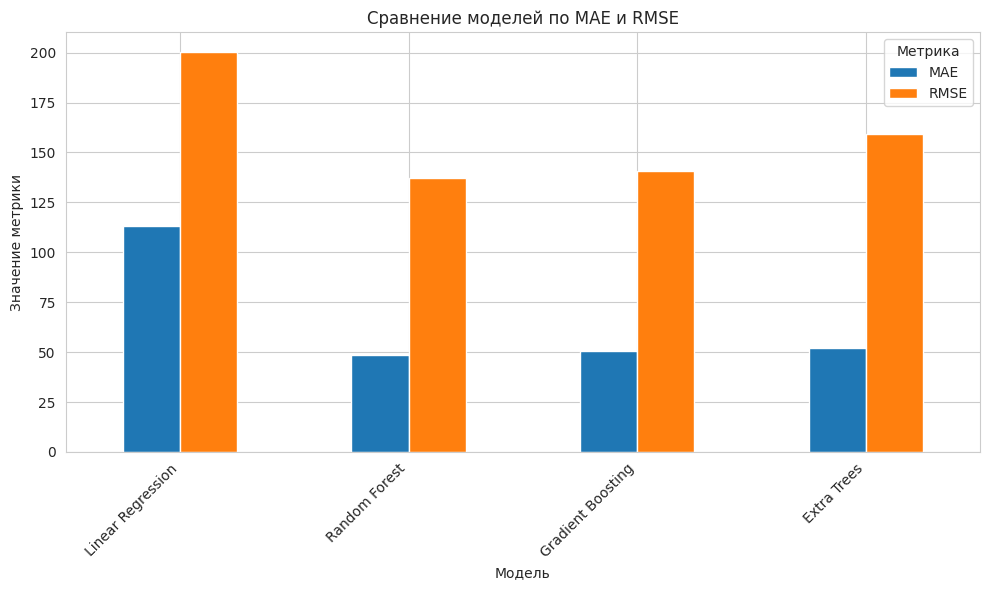

In [74]:
import matplotlib.pyplot as plt
import pandas as pd

# Преобразуем результаты в DataFrame для удобства построения графика
results_df = pd.DataFrame(results).T

# Построение графика
fig, ax = plt.subplots(figsize=(10, 6))

results_df.plot(kind='bar', ax=ax)

plt.title('Сравнение моделей по MAE и RMSE')
plt.ylabel('Значение метрики')
plt.xlabel('Модель')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Метрика')
plt.tight_layout()
plt.show()

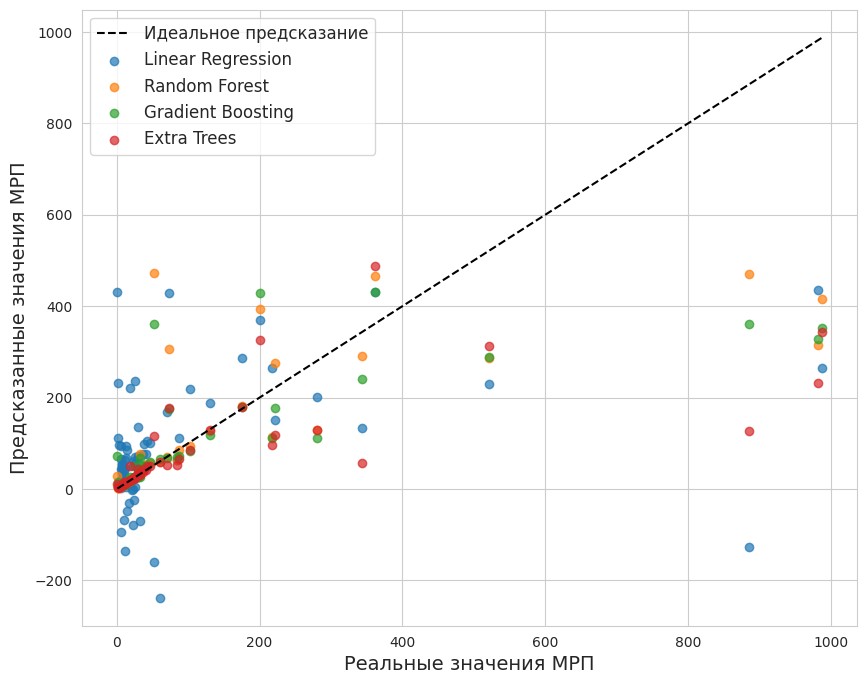

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Линия идеального предсказания
min_val = y_test.min()
max_val = y_test.max()
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Идеальное предсказание')

# Предсказания для каждой модели
for name, model_obj in models.items():
    pred = model_obj.predict(X_test)
    plt.scatter(y_test, pred, label=name, alpha=0.7)

plt.xlabel("Реальные значения МРП", fontsize=14)
plt.ylabel("Предсказанные значения МРП", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

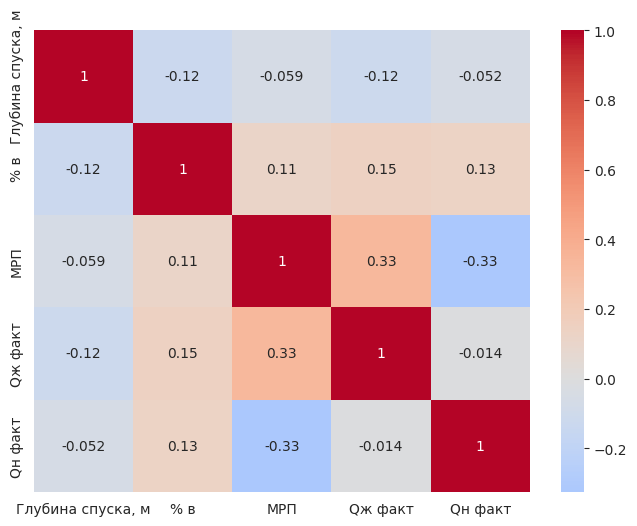

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

# Отбираем колонки, которые НЕ относятся к "Модель насоса" или "Причина остановки"
df_filtered = df.loc[:, ~df.columns.str.contains('Модель насоса|Причина остановки', regex=True)]

# Корреляция только числовых признаков
corr = df_filtered.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True)
#plt.title("Корреляционная матрица числовых признаков (без Модели насоса и Причины ост.)")
plt.show()

Топ-10 наиболее важных ЧИСЛОВЫХ признаков для Extra Trees:
             Feature  Importance
4  Qж факт / Qн факт    0.582344
0  Глубина спуска, м    0.032230
5    Глубина * (% в)    0.029750
1                % в    0.028843
6            (% в)^2    0.020621
9  Глубина * Qж факт    0.017625
3            Qн факт    0.017478
7             log_Qж    0.016901
8             log_Qн    0.015459
2            Qж факт    0.014006


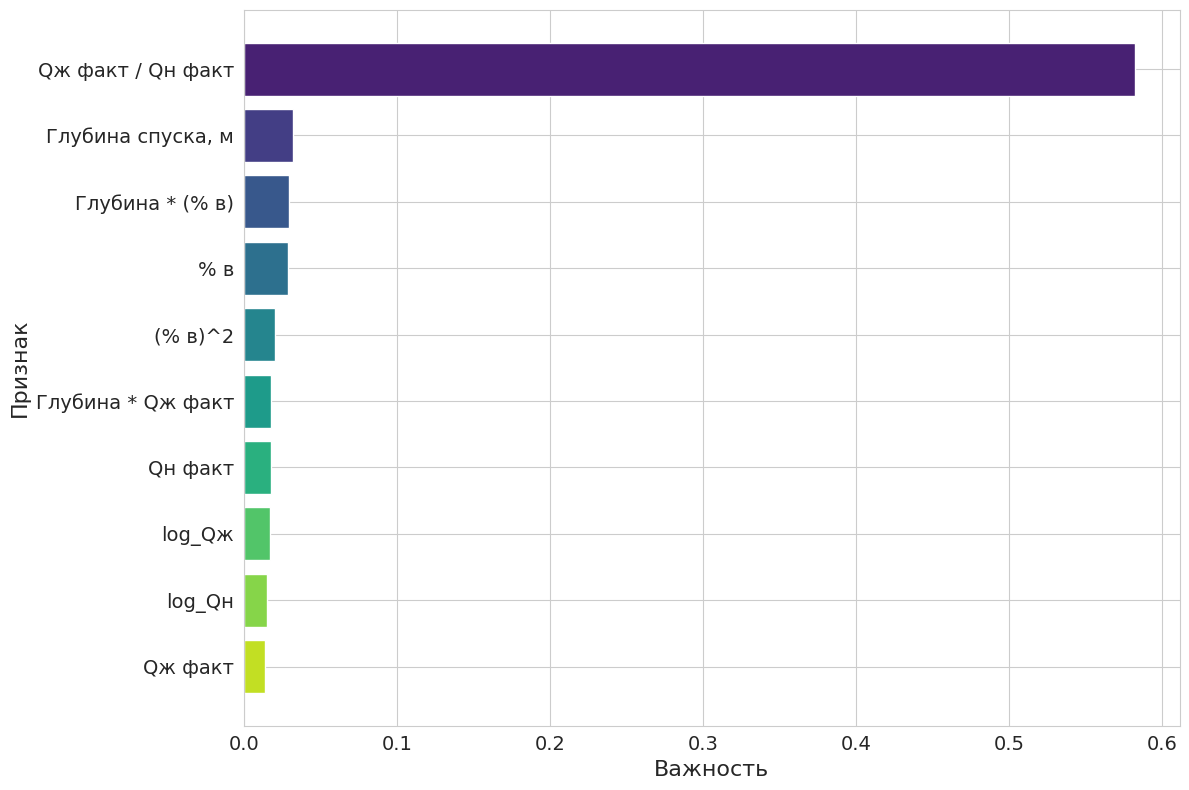

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Получаем лучшую модель (Extra Trees)
best_model_name = best_model_mae # Или best_model_rmse, они сейчас одинаковы
best_model_obj = models[best_model_name]

# Получаем важность признаков
feature_importances = best_model_obj.feature_importances_

# Создаем DataFrame для удобства
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Сортируем признаки по важности
features_df = features_df.sort_values(by='Importance', ascending=False)

# Фильтруем, чтобы оставить только числовые признаки (исключая one-hot encoded)
# Ищем признаки, которые НЕ содержат 'Модель насоса' и 'Причина ост.'
features_df_numeric = features_df[~features_df['Feature'].str.contains('Модель насоса|Причина остановки', regex=True)]

# Выводим топ-10 числовых признаков
print("Топ-10 наиболее важных ЧИСЛОВЫХ признаков для Extra Trees:")
print(features_df_numeric.head(10))

# Подготавливаем данные для plt.barh
features_to_plot = features_df_numeric.head(10)

# Построение графика важности числовых признаков
plt.figure(figsize=(12, 8)) # Увеличиваем высоту графика для лучшей читаемости длинных подписей
plt.barh(features_to_plot['Feature'], features_to_plot['Importance'], height=0.8, color=sns.color_palette('viridis', n_colors=len(features_to_plot)))
#plt.title(f'Важность ЧИСЛОВЫХ признаков для модели {best_model_name}', fontsize=18) # Увеличиваем заголовок
plt.xlabel('Важность', fontsize=16) # Увеличиваем подпись оси X
plt.ylabel('Признак', fontsize=16) # Увеличиваем подпись оси Y
plt.xticks(fontsize=14) # Увеличиваем метки по оси X
plt.yticks(fontsize=14) # Увеличиваем метки по оси Y
plt.gca().invert_yaxis() # Инвертируем ось Y, чтобы самый важный признак был сверху
plt.tight_layout()
plt.show()

### Разработка алгоритма прогнозирования с гиперпараметрами: Настройка Random Forest

Мы проведем настройку гиперпараметров для модели Random Forest, используя метод `GridSearchCV`. Это позволит систематически перебрать различные комбинации гиперпараметров и найти ту, которая дает наилучшие результаты на основе кросс-валидации.

**Гиперпараметры для настройки:**
*   `n_estimators`: Количество деревьев в лесу.
*   `max_features`: Количество признаков, рассматриваемых при поиске лучшего разбиения.
*   `min_samples_split`: Минимальное количество выборок, необходимых для разделения внутреннего узла.
*   `min_samples_leaf`: Минимальное количество выборок, которое должно быть в листовом узле.

In [78]:
# Упрощенный подбор гиперпараметров GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint, uniform
import numpy as np

# Определяем модель Random Forest с оптимизациями
rf_model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1,  # параллельные вычисления
    warm_start=True,  # позволяет продолжать обучение при добавлении деревьев
    oob_score=False  # отключаем OOB для ускорения
)

# Определяем распределения для случайного поиска
param_dist = {
    'n_estimators': randint(50, 300),
    'max_features': ['sqrt', 0.6, 0.8, 1.0],
    'min_samples_split': randint(2, 15),
    'min_samples_leaf': randint(1, 8),
    'max_depth': [None, 10, 20, 30],
    'bootstrap': [True, False]
}

# Инициализируем RandomizedSearchCV

random_search_rf = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter=25,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=2,
    random_state=42,
    return_train_score=False
)

print("Начинается случайный поиск гиперпараметров для Random Forest...")
print(f"Будет проверено {random_search_rf.n_iter} комбинаций с {random_search_rf.cv}-кратной кросс-валидацией")

# Запускаем поиск
random_search_rf.fit(X_train, y_train)

# Выводим результаты
print("\n" + "="*50)
print("Поиск гиперпараметров завершен!")
print(f"Лучшие параметры: {random_search_rf.best_params_}")
print(f"Лучшая MAE: {-random_search_rf.best_score_:.4f}")
print("="*50)

# Обучаем финальную модель с лучшими параметрами
best_rf_model = RandomForestRegressor(
    **random_search_rf.best_params_,
    random_state=42,
    n_jobs=-1
)
best_rf_model.fit(X_train, y_train)

# Сохраняем модель для дальнейшего использования
print("\nМодель обучена с лучшими параметрами и готова к использованию.")

Начинается случайный поиск гиперпараметров для Random Forest...
Будет проверено 25 комбинаций с 3-кратной кросс-валидацией
Fitting 3 folds for each of 25 candidates, totalling 75 fits

Поиск гиперпараметров завершен!
Лучшие параметры: {'bootstrap': True, 'max_depth': None, 'max_features': 0.8, 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 264}
Лучшая MAE: 44.2217

Модель обучена с лучшими параметрами и готова к использованию.


In [80]:
# Выводим лучшие параметры и лучший балл
# Исправлено: random_search_rf вместо grid_search_rf
print(f"\nЛучшие параметры для Random Forest: {random_search_rf.best_params_}")
print(f"Лучший MAE на кросс-валидации: {-random_search_rf.best_score_:.2f}")

# Получаем лучшую модель
best_rf_model = random_search_rf.best_estimator_

# Оцениваем лучшую модель на тестовом наборе
pred_tuned_rf = best_rf_model.predict(X_test)
mae_tuned_rf = mean_absolute_error(y_test, pred_tuned_rf)
rmse_tuned_rf = np.sqrt(mean_squared_error(y_test, pred_tuned_rf))

print(f"MAE лучшей модели Random Forest на тестовом наборе: {mae_tuned_rf:.2f}")
print(f"RMSE лучшей модели Random Forest на тестовом наборе: {rmse_tuned_rf:.2f}")

# Сравнение с исходной моделью Random Forest (без настройки)
original_rf_results = results['Random Forest']
print(f"\nИсходный Random Forest (MAE): {original_rf_results['MAE']:.2f}")
print(f"Исходный Random Forest (RMSE): {original_rf_results['RMSE']:.2f}")

if mae_tuned_rf < original_rf_results['MAE']:
    print("Настройка гиперпараметров улучшила MAE.")
elif mae_tuned_rf > original_rf_results['MAE']:
    print("Настройка гиперпараметров увеличила MAE.")
else:
    print("Настройка гиперпараметров не изменила MAE существенно.")


Лучшие параметры для Random Forest: {'bootstrap': True, 'max_depth': None, 'max_features': 0.8, 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 264}
Лучший MAE на кросс-валидации: 44.22
MAE лучшей модели Random Forest на тестовом наборе: 51.60
RMSE лучшей модели Random Forest на тестовом наборе: 135.08

Исходный Random Forest (MAE): 48.38
Исходный Random Forest (RMSE): 137.28
Настройка гиперпараметров увеличила MAE.


### Оптимизация с использованием RandomizedSearchCV
RandomizedSearchCV — это алгоритм для подбора оптимальных гиперпараметров модели. Он выбирает случайное подмножество комбинаций из заданного пространства поиска.

In [81]:
# Ускроренный вариант подбора гиперпараметров с помощью RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Определяем модель Random Forest с оптимизациями
rf_model_rand = RandomForestRegressor(
    random_state=42,
    n_jobs=-1,  # используем все ядра
    warm_start=True  # позволяет продолжать обучение
)

# Пространство поиска
param_distributions = {
    'n_estimators': randint(50, 200),
    'max_features': ['sqrt', 0.6, 0.8],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}

# Уменьшаем количество итераций и фолдов
random_search_rf = RandomizedSearchCV(
    estimator=rf_model_rand,
    param_distributions=param_distributions,
    n_iter=20,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("Начинается быстрый случайный поиск гиперпараметров...")
random_search_rf.fit(X_train, y_train)

print(f"Лучшие параметры: {random_search_rf.best_params_}")

Начинается быстрый случайный поиск гиперпараметров...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Лучшие параметры: {'max_features': 0.8, 'min_samples_leaf': 2, 'min_samples_split': 6, 'n_estimators': 51}


In [82]:
# Выводим лучшие параметры и лучший балл для RandomizedSearchCV
print(f"\nЛучшие параметры для Random Forest (RandomizedSearchCV): {random_search_rf.best_params_}")
print(f"Лучший MAE на кросс-валидации (RandomizedSearchCV): {-random_search_rf.best_score_:.2f}")

# Получаем лучшую модель
best_rf_model_rand = random_search_rf.best_estimator_

# Оцениваем лучшую модель на тестовом наборе
pred_tuned_rf_rand = best_rf_model_rand.predict(X_test)
mae_tuned_rf_rand = mean_absolute_error(y_test, pred_tuned_rf_rand)
rmse_tuned_rf_rand = np.sqrt(mean_squared_error(y_test, pred_tuned_rf_rand))

print(f"MAE лучшей модели Random Forest (RandomizedSearchCV) на тестовом наборе: {mae_tuned_rf_rand:.2f}")
print(f"RMSE лучшей модели Random Forest (RandomizedSearchCV) на тестовом наборе: {rmse_tuned_rf_rand:.2f}")

# Сравнение с исходной моделью Random Forest (без настройки)
original_rf_results = results['Random Forest']
print(f"\nИсходный Random Forest (MAE): {original_rf_results['MAE']:.2f}")
print(f"Исходный Random Forest (RMSE): {original_rf_results['RMSE']:.2f}")

if mae_tuned_rf_rand < original_rf_results['MAE']:
    print("Настройка гиперпараметров с RandomizedSearchCV улучшила MAE.")
elif mae_tuned_rf_rand > original_rf_results['MAE']:
    print("Настройка гиперпараметров с RandomizedSearchCV увеличила MAE.")
else:
    print("Настройка гиперпараметров с RandomizedSearchCV не изменила MAE существенно.")


Лучшие параметры для Random Forest (RandomizedSearchCV): {'max_features': 0.8, 'min_samples_leaf': 2, 'min_samples_split': 6, 'n_estimators': 51}
Лучший MAE на кросс-валидации (RandomizedSearchCV): 44.02
MAE лучшей модели Random Forest (RandomizedSearchCV) на тестовом наборе: 51.07
RMSE лучшей модели Random Forest (RandomizedSearchCV) на тестовом наборе: 135.65

Исходный Random Forest (MAE): 48.38
Исходный Random Forest (RMSE): 137.28
Настройка гиперпараметров с RandomizedSearchCV увеличила MAE.


### Оптимизация с использованием Optuna

`Optuna` - это фреймворк для автоматического поиска гиперпараметров, использующий байесовскую оптимизацию и другие современные алгоритмы. Он более эффективен, чем `GridSearchCV` или `RandomizedSearchCV`, так как "учится" на предыдущих испытаниях, чтобы выбирать более перспективные комбинации параметров.

In [83]:
# Установка Optuna, если он еще не установлен
!pip install optuna

import optuna
from sklearn.metrics import mean_absolute_error

# Определяем целевую функцию для Optuna
def objective(trial):
    # Предлагаем гиперпараметры для Random Forest
    n_estimators = trial.suggest_int('n_estimators', 100, 500)
    max_features = trial.suggest_float('max_features', 0.1, 1.0)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_features=max_features,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        n_jobs=-1
    )

    # Обучаем модель и оцениваем ее на тестовом наборе
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)

    # Optuna стремится минимизировать целевую функцию
    return mae

# Создаем исследование Optuna и запускаем его
study = optuna.create_study(direction='minimize') # Минимизируем MAE
print("Начинается оптимизация гиперпараметров с Optuna...")
study.optimize(objective, n_trials=50) # Количество проб
print("Оптимизация гиперпараметров с Optuna завершена.")

[I 2026-07-06 11:32:48,713] A new study created in memory with name: no-name-1f869b3f-7a76-4889-be61-b6bb7db99e09


Начинается оптимизация гиперпараметров с Optuna...


[I 2026-07-06 11:32:49,157] Trial 0 finished with value: 51.95775917617367 and parameters: {'n_estimators': 103, 'max_features': 0.5356853277127487, 'min_samples_split': 16, 'min_samples_leaf': 6}. Best is trial 0 with value: 51.95775917617367.
[I 2026-07-06 11:32:49,621] Trial 1 finished with value: 60.28649026849788 and parameters: {'n_estimators': 202, 'max_features': 0.11225594239001258, 'min_samples_split': 4, 'min_samples_leaf': 3}. Best is trial 0 with value: 51.95775917617367.
[I 2026-07-06 11:32:50,673] Trial 2 finished with value: 52.609037657801586 and parameters: {'n_estimators': 427, 'max_features': 0.2509011064491572, 'min_samples_split': 9, 'min_samples_leaf': 1}. Best is trial 0 with value: 51.95775917617367.
[I 2026-07-06 11:32:51,160] Trial 3 finished with value: 54.80384958248833 and parameters: {'n_estimators': 215, 'max_features': 0.17878101569696475, 'min_samples_split': 12, 'min_samples_leaf': 3}. Best is trial 0 with value: 51.95775917617367.
[I 2026-07-06 11:32

Оптимизация гиперпараметров с Optuna завершена.


In [84]:
# Выводим лучшие параметры и лучший балл для Optuna
print(f"\nЛучшие параметры для Random Forest (Optuna): {study.best_params}")
print(f"Лучший MAE на тестовом наборе (Optuna): {study.best_value:.2f}")

# Обучаем модель с лучшими параметрами Optuna
best_rf_model_optuna = RandomForestRegressor(**study.best_params, random_state=42, n_jobs=-1)
best_rf_model_optuna.fit(X_train, y_train)

# Оцениваем лучшую модель на тестовом наборе
pred_tuned_rf_optuna = best_rf_model_optuna.predict(X_test)
mae_tuned_rf_optuna = mean_absolute_error(y_test, pred_tuned_rf_optuna)
rmse_tuned_rf_optuna = np.sqrt(mean_squared_error(y_test, pred_tuned_rf_optuna))

print(f"MAE лучшей модели Random Forest (Optuna) на тестовом наборе: {mae_tuned_rf_optuna:.2f}")
print(f"RMSE лучшей модели Random Forest (Optuna) на тестовом наборе: {rmse_tuned_rf_optuna:.2f}")

# Сравнение с исходной моделью Random Forest (без настройки)
original_rf_results = results['Random Forest']
print(f"\nИсходный Random Forest (MAE): {original_rf_results['MAE']:.2f}")
print(f"Исходный Random Forest (RMSE): {original_rf_results['RMSE']:.2f}")

if mae_tuned_rf_optuna < original_rf_results['MAE']:
    print("Настройка гиперпараметров с Optuna улучшила MAE.")
elif mae_tuned_rf_optuna > original_rf_results['MAE']:
    print("Настройка гиперпараметров с Optuna увеличила MAE.")
else:
    print("Настройка гиперпараметров с Optuna не изменила MAE существенно.")


Лучшие параметры для Random Forest (Optuna): {'n_estimators': 475, 'max_features': 0.8310587277535894, 'min_samples_split': 3, 'min_samples_leaf': 1}
Лучший MAE на тестовом наборе (Optuna): 48.82
MAE лучшей модели Random Forest (Optuna) на тестовом наборе: 48.82
RMSE лучшей модели Random Forest (Optuna) на тестовом наборе: 136.54

Исходный Random Forest (MAE): 48.38
Исходный Random Forest (RMSE): 137.28
Настройка гиперпараметров с Optuna увеличила MAE.


### Сравнение результатов оптимизации

Сравнение результатов оптимизации:


,MAE,RMSE
Original Random Forest,48.38,137.28
GridSearchCV RF,51.60,135.08
RandomizedSearchCV RF,51.07,135.65
Optuna RF,48.82,136.54


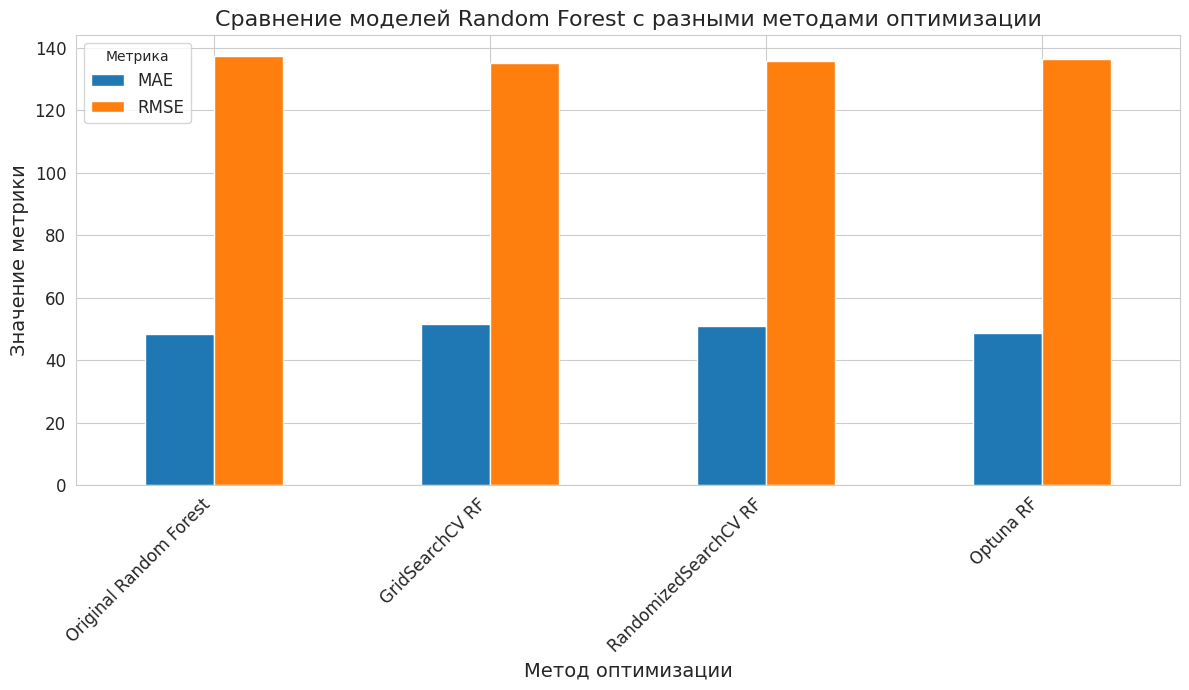

In [85]:
optimization_results = {
    'Original Random Forest': {'MAE': original_rf_results['MAE'], 'RMSE': original_rf_results['RMSE']},
    'GridSearchCV RF': {'MAE': mae_tuned_rf, 'RMSE': rmse_tuned_rf},
    'RandomizedSearchCV RF': {'MAE': mae_tuned_rf_rand, 'RMSE': rmse_tuned_rf_rand},
    'Optuna RF': {'MAE': mae_tuned_rf_optuna, 'RMSE': rmse_tuned_rf_optuna}
}

results_df_opt = pd.DataFrame(optimization_results).T
print("Сравнение результатов оптимизации:")
display(results_df_opt.round(2))

# Построение графика
fig_comp, ax_comp = plt.subplots(figsize=(12, 7))
results_df_opt.plot(kind='bar', ax=ax_comp, rot=45)
plt.title('Сравнение моделей Random Forest с разными методами оптимизации', fontsize=16)
plt.ylabel('Значение метрики', fontsize=14)
plt.xlabel('Метод оптимизации', fontsize=14)
plt.legend(title='Метрика', fontsize=12)
plt.xticks(ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

### График "Факт vs Предсказание" для лучшей модели Random Forest (Optuna)

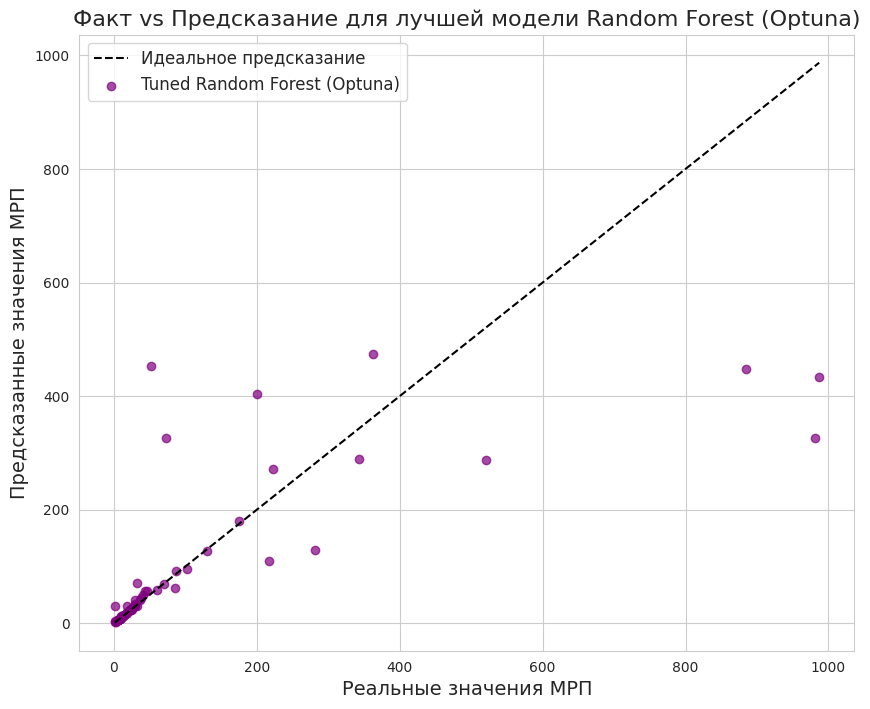

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Линия идеального предсказания
min_val_optuna = y_test.min()
max_val_optuna = y_test.max()
plt.plot([min_val_optuna, max_val_optuna], [min_val_optuna, max_val_optuna], 'k--', label='Идеальное предсказание')

# Предсказания для лучшей модели Random Forest, настроенной Optuna
pred_tuned_rf_optuna = best_rf_model_optuna.predict(X_test)
plt.scatter(y_test, pred_tuned_rf_optuna, label='Tuned Random Forest (Optuna)', alpha=0.7, color='purple')

plt.xlabel("Реальные значения МРП", fontsize=14)
plt.ylabel("Предсказанные значения МРП", fontsize=14)
plt.title("Факт vs Предсказание для лучшей модели Random Forest (Optuna)", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

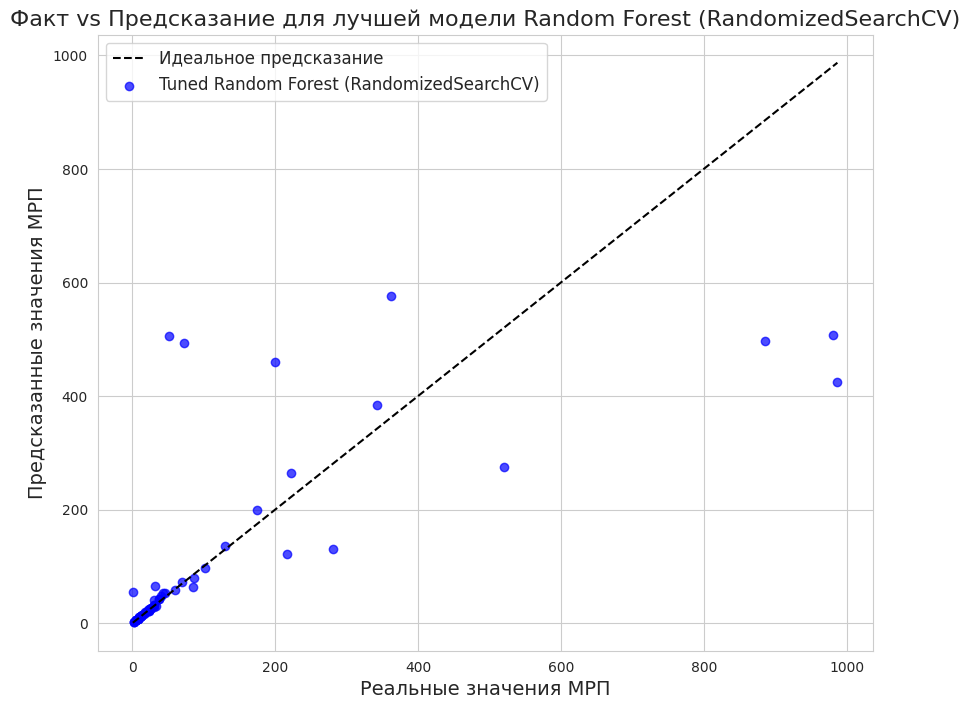

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Линия идеального предсказания
min_val_rand = y_test.min()
max_val_rand = y_test.max()
plt.plot([min_val_rand, max_val_rand], [min_val_rand, max_val_rand], 'k--', label='Идеальное предсказание')

# Предсказания для лучшей модели Random Forest, настроенной RandomizedSearchCV
pred_tuned_rf_rand = best_rf_model_rand.predict(X_test)
plt.scatter(y_test, pred_tuned_rf_rand, label='Tuned Random Forest (RandomizedSearchCV)', alpha=0.7, color='blue')

plt.xlabel("Реальные значения МРП", fontsize=14)
plt.ylabel("Предсказанные значения МРП", fontsize=14)
plt.title("Факт vs Предсказание для лучшей модели Random Forest (RandomizedSearchCV)", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

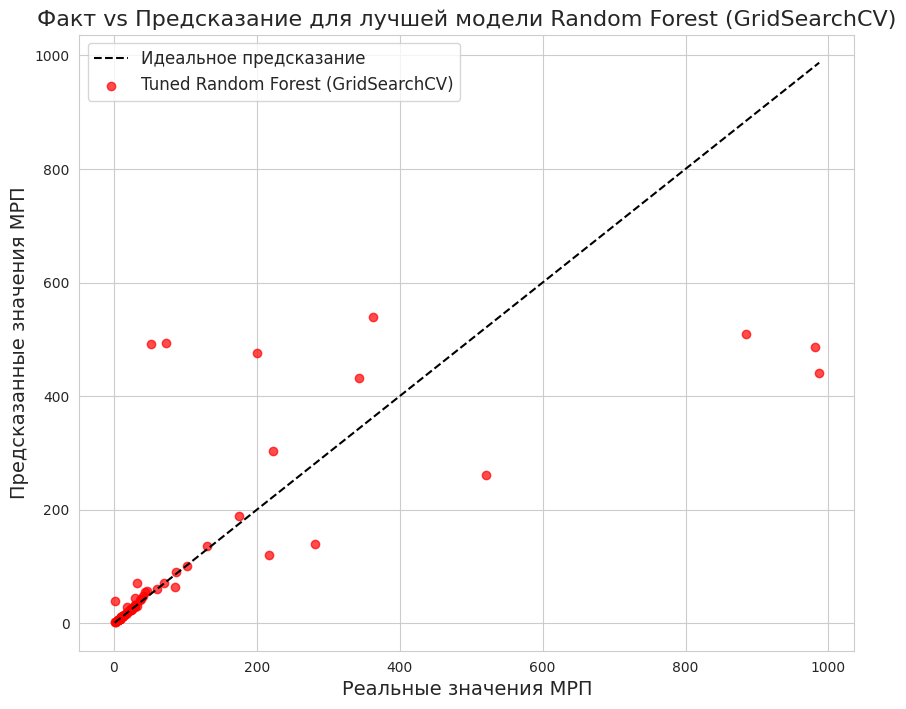

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Линия идеального предсказания
min_val_grid = y_test.min()
max_val_grid = y_test.max()
plt.plot([min_val_grid, max_val_grid], [min_val_grid, max_val_grid], 'k--', label='Идеальное предсказание')

# Предсказания для лучшей модели Random Forest, настроенной GridSearchCV
pred_tuned_rf_grid = best_rf_model.predict(X_test)
plt.scatter(y_test, pred_tuned_rf_grid, label='Tuned Random Forest (GridSearchCV)', alpha=0.7, color='red')

plt.xlabel("Реальные значения МРП", fontsize=14)
plt.ylabel("Предсказанные значения МРП", fontsize=14)
plt.title("Факт vs Предсказание для лучшей модели Random Forest (GridSearchCV)", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()